<a href="https://colab.research.google.com/github/Uzayulucay/RP_4q_code/blob/main/1D_domain_wall_num.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from collections import Counter

In [ ]:
from sympy import symbols, lambdify, I, conjugate, exp, diff, re, im, expand_complex, expand, simplify, sin, cos, integrate, sqrt

In [ ]:
from scipy.optimize import minimize

In [ ]:
def coef(recomp,imcomp,nmax):
    """This is for symbolic checks.
    """
    Rx = []
    Ix = []

    for i in np.arange(nmax + 1):
      Rx.append(symbols(f"{recomp}_{i}",real = True))
      Ix.append(symbols(f"{imcomp}_{i}",real = True))

    return Rx+Ix[1:]

In [ ]:
param_sym1 = np.concatenate(([symbols("Q")],coef("A_x","B_x",nmax),coef("A_z","B_z",nmax)))
param_sym1

NameError: name 'nmax' is not defined

In [ ]:
def indexes1(nmax):
  """Produces a list of coordinates of all points in reciprocal space. It also
  generates the inverted coordinates for complex conjugate variables.
  """

  indices = []
  ind2 = []
  for j in np.arange(nmax + 1):
      indices.append(j)
      ind2.append(-j)

  return indices, ind2

In [ ]:
def combinations(nmax):
  """Takes in the integer bounds and produces lists for all distinct combinations
  of the indices that occur in the fourth order terms, as well as their combinatorial factors.
  """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,4)) #generate a list of 4 integers between -nmax and nmax

  #if the sum of integers within a list is 0 add all of its permutations to list1
  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == 0:
      perm = list(set(itertools.permutations(allcomb[i],4)))
      for j in perm:
        list1.append(list(j))


  comb_list1 = []
  comb_list2 = []
  for a in list1:
   #combine the lists into 4 vectors with 2 components
    comb_list1.append(tuple(sorted(a))) #ordering the vectors
    comb_list2.append(tuple(sorted(a[:2])+sorted(a[2:])))
      #ordering the first two elements and the last two separately for the mixed 4th order terms

  pos_comb1 = list(set(comb_list1)) #select all the distinct elements
  pos_comb2 = list(set(comb_list2))
  comb_fac1 = []
  comb_fac2 = []

  #count the distinct permutations of an element to find the combinatorial factors
  for i in range(len(pos_comb1)):
    comb_fac1.append(len(set(list(itertools.permutations(pos_comb1[i])))))

  for j in range(len(pos_comb2)):
    comb_fac2.append(len(set(list(itertools.permutations(pos_comb2[j][2:]))))*len(set(list(itertools.permutations(pos_comb2[j][:2])))))
  return pos_comb1, comb_fac1, pos_comb2, comb_fac2

In [ ]:
def comb_three(allcomb,N):
  """Similar to the first part of 'combinations', takes in all possible lists of 4 integers
  and the required N to produce the derivative terms. We require the sum of all elements
  to equal to minus the provided N.
  """

  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == -N:
      perm = list(set(itertools.permutations(allcomb[i],3)))
      for j in perm:
        list1.append(list(j))
  return list1

In [ ]:
def comb_lists(cr1, cor):
  """Lists are combined in groups of three and only after finding the distinct
  combinations, the fourth elements are added in order to find the combinatorial
  factors.
  """

  comb_list4b = []
  comb_list2b = []
  for a in cr1:
      comb_list4b.append(tuple(sorted(a)))
      comb_list2b.append(tuple(a[:1]+sorted(a[1:]))) #order the last two separately from the first element

  pos_comb4b = list(set(comb_list4b))
  pos_comb2b = list(set(comb_list2b))

  pc4b = []
  pc2b = []

  for el in pos_comb4b:
    pc4b.append(tuple(cor+list(el)))
    #adding the indices of the coefficient which we take the derivative with respect to

  for l in pos_comb2b:
    pc2b.append(tuple(cor+list(l)))

  return pc4b, pc2b

In [ ]:
def combinations_der(x,nmax):
  """This produces the indices for the derivatives of the fourth power terms and
  their corresponding combinatorial factors.
  Supply x = [(a,b)] """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,3)) #this time lists contain 3 elements
  ind = [x,-x]
  #we need the vector and its inversion to demand complex conjugates are not treated separately

  coord = []
  for i in ind:
    coord.append(comb_three(allcomb, i))


  #derivative wrt the coefficient characterized by x and the complex conjugate of that term
  pc4b1, pc2b1 = comb_lists(coord[0],[x])
  pc4b2, pc2b2 = comb_lists(coord[1],[-x])

  comb_fac4b = []
  comb_fac2b = []

  pc4 = list(set(sorted(pc4b1 + pc4b2)))
  pc2 = list(set(pc2b1 + pc2b2))


  prefac4b = []
  prefac2b = []

  for i in range(len(pc4)): #combinatorial factors
    comb_fac4b.append(len(set(list(itertools.permutations(pc4[i])))))
    prefac4b.append(pc4[i].count(pc4[i][0]))


  for i in range(len(pc2)): #combinatorial factors for the mixed terms
    comb_fac2b.append(len(set(list(itertools.permutations(pc2[i][:2]))))*len(set(list(itertools.permutations(pc2[i][2:])))))
    prefac2b.append(pc2[i][:2].count(pc2[i][0]))


  cf4 = np.array(prefac4b) * np.array(comb_fac4b)
  cf2 = np.array(prefac2b) * np.array(comb_fac2b)

  return pc4, cf4, pc2, cf2

In [ ]:
def B4xyz(com,fac,C,indx):
  """Calculation of the 4th order terms that are not mixed (e.g. mx^4).
  Looks at the coordinates stored in com (the array of indices of the 4th power terms)
  and locates each index within the list of coordinates.

  C: The list of coordinates.
  com: The list of indices for the 4th power terms.
  fac: combinatorial factors.
  """

  a = []
  for i in range(len(com)):
    b = 1
    for j in range(4):
      b *= C[indx.index(com[i][j])]
    a.append(b)

  c = a*np.array(fac)

  ad = sum(c)

  return ad #expand(Add(*a))

In [ ]:
def factors(tup,comp,L):
  """comp is given as either [1,1] or [i,-i] depending on whether we are taking
  a derivative wrt the real part (A) or the imaginary part (B). Values in comp are
  the prefactors we get after taking the derivative. tup is the index of a particular coordinate
  in the list of coordinates.
  """
  if tup < L:
    s = comp[0]
  else:
    s = comp[1]

  return s

In [ ]:
def b4xyz(com,fac,C,comp,indx):
  """Calculation of the derivatives of the 4th order non-mixed terms.
  """
  L = int(len(indx) + 1)/2
  a = []
  for i in range(len(com)):
    b = factors(indx.index(com[i][0]),comp,L)
    for k in range(1,4):
      b *= C[indx.index(com[i][k])]
    a.append(b)

  c = a*np.array(fac)

  ad = sum(c)

  return ad #expand(Add(*a))

In [ ]:
def B2xyz(com, fac, C1, C2,indx):
  """Calculation of the 4th order terms that are mixed (e.g. mx^2my^2).
  That is why C1 and C2 contain coefficients of different magnetization components.
  """

  a = []
  for i in range(len(com)):
    b = 1
    for j in range(2):
      b *= C1[indx.index(com[i][j])]
    for k in range(2,4):
      b *= C2[indx.index(com[i][k])]

    a.append(np.prod(b))
  c = a*np.array(fac)

  ad = sum(c)

  return ad

In [ ]:
def b2xyz(com, fac, C1, C2,comp,indx):
  """Calculation of the derivatives of the 4th order mixed terms.
  """
  a = []
  L = int(len(indx) + 1)/2
  for i in range(len(com)):
    b = factors(indx.index(com[i][0]),comp,L)*C1[indx.index(com[i][1])]
    for k in range(2,4):
      b *= C2[indx.index(com[i][k])]
    a.append(b)

  c = a*np.array(fac)

  ad = sum(c)

  return ad

In [ ]:
def energy1(parameters, nmax, J, K, D, lamb, H, cod, com):

  indx_pos, indx_neg = indexes1(nmax)
  indx = indx_pos + indx_neg[1:] #a list of ALL coordinates in reciprocal space
  arx, arz = np.split(parameters[1:],2) #equally divide for x,y,z components after removing Q's
  L = int((len(arx) + 1)/2) #to divide each x,y,z component into real and imaginary parts
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx #mq coefficients and their complex conjugates
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Z4 = np.concatenate((Posz,Negz[1:]))


  SxSx = 2*Posx*Negx
  SxSx[0] = SxSx[0]/2
  SzSz = 2*Posz*Negz
  SzSz[0] = SzSz[0]/2

  DMI = parameters[0]*(indx_pos * Posz*Negx + indx_neg * Posx*Negz)
  DMI[0] = DMI[0]/2
  #SqS-q terms

  S4x = B4xyz(com[0],com[1],X4,indx)
  S4z = B4xyz(com[0],com[1],Z4,indx)
  S2zx = B2xyz(com[2],com[3],Z4,X4,indx)


  energy = sum(J/2*parameters[0]**2*np.array(indx_pos)**2*(SxSx + SzSz) + 2*D*1j*DMI + K/2*SxSx) + lamb*(S4x + S4z + 2*S2zx - 2*sum(SxSx + SzSz) + 1) - Az[0]*H

  return np.real(energy)

In [ ]:
def derivatives1(indices,parameters, comp,nmax, J, K, D, lamb, H, cod, com):
  """derivatives of energy wrt the Fourier coefficients. The derivative for the
  coefficient associated with (0,0) is treated differently since it has no imaginary part"""

  in_pos, in_neg = indexes1(nmax)
  indx = in_pos + in_neg[1:]
  arx, arz = np.split(parameters[1:],2)
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Z4 = np.concatenate((Posz,Negz[1:]))


  dEx = []
  dEz = []
  for i in range(len(indices)):

    indX = in_pos.index(indices[i])
    Cod = cod[indX]
    dS4x = b4xyz(Cod[0], Cod[1],X4,comp,indx)
    dS4z = b4xyz(Cod[0], Cod[1],Z4,comp,indx)

    dS2xz = b2xyz(Cod[2], Cod[3],X4, Z4,comp,indx)
    dS2zx = b2xyz(Cod[2], Cod[3],Z4, X4,comp,indx)

    dSxSx = 2.0*comp[1]*Posx[indX] + 2.0*comp[0]*Negx[indX]
    dSzSz = 2.0*comp[1]*Posz[indX] + 2.0*comp[0]*Negz[indX]
    q = parameters[0]
    dDMx = q*(comp[1] * in_pos[indX]*Posz[indX] + comp[0]*in_neg[indX]*Negz[indX])
    dDMz = q*(comp[1] * in_neg[indX]*Posx[indX] + comp[0]*in_pos[indX]*Negx[indX])


    if indX == 0:
      dSxSx = dSxSx/2
      dSzSz = dSzSz/2
      dDMx = dDMx/2
      dDMz = dDMz/2
      Hfield = -H
    else:
      Hfield = 0

    dEx.append(lamb*(dS4x + 2*dS2xz - 2*dSxSx) +
    J/2*q**2*indX**2*dSxSx + 2*D*1j*dDMx + K/2*dSxSx)

    dEz.append(lamb*(dS4z + 2*dS2zx - 2*dSzSz) +
    J/2*q**2*indX**2*dSzSz + 2*D*1j*dDMz + Hfield)

  return np.array(dEx), np.array(dEz)

In [ ]:
def der_q1(parameters,nmax, J, K, D, lamb, H, cod, com):

  indx_pos, indx_neg = indexes1(nmax)
  indx = indx_pos + indx_neg[1:] #a list of ALL coordinates in reciprocal space
  arx, arz = np.split(parameters[1:],2) #equally divide for x,y,z components after removing Q's
  L = int((len(arx) + 1)/2) #to divide each x,y,z component into real and imaginary parts
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx #mq coefficients and their complex conjugates
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Z4 = np.concatenate((Posz,Negz[1:]))

  SxSx = 2*Posx*Negx
  SxSx[0] = SxSx[0]/2
  SzSz = 2*Posz*Negz
  SzSz[0] = SzSz[0]/2

  dDMI = indx_pos * Posz*Negx + indx_neg * Posx*Negz
  dDMI[0] = dDMI[0]/2
  #SqS-q terms

  S4x = B4xyz(com[0],com[1],X4,indx)
  S4z = B4xyz(com[0],com[1],Z4,indx)
  S2zx = B2xyz(com[2],com[3],Z4,X4,indx)


  derq = sum(J*parameters[0]*np.array(indx_pos)**2*(SxSx + SzSz) + 2*D*1j*dDMI)

  return derq

In [ ]:
def der1(parameters,nmax, J, K, D, lamb, H, cod, com):
  """The full gradient function"""
  indx_pos, indx_neg = indexes1(nmax)
  indx = indx_pos + indx_neg[1:] #a list of ALL coordinates in reciprocal space

  Eax, Eaz = derivatives1(indx_pos,parameters,[1,1],nmax, J, K, D, lamb, H, cod, com)
  Ebx, Ebz = derivatives1(indx_pos[1:],parameters,[1j,-1j],nmax, J, K, D, lamb, H, cod, com)
  derQ = der_q1(parameters, nmax, J, K, D, lamb, H, cod, com)

  return np.real(np.concatenate((np.array([derQ]),Eax,Ebx,Eaz,Ebz))) #d_q1x,d_q2x,d_q1y,d_q2y,

In [ ]:
def input_arrays1(zero_ar,param,nmax):
  """This is to arrange arrays to easily write the initial values"""
  arx, arz = np.split(param[1:],2)
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  ar_zero = np.copy(zero_ar)
  all_arrays = [Ax,Bx,Az,Bz]
  e = indexes1(nmax)[0]
  for k in range(4):
    for i in range(len(e)):
      ar_zero[k][e[i]] = all_arrays[k][i]
  return ar_zero

In [ ]:
def generate_param1(inp_ar,nmax):
  """Converts the matrices from input_arrays into a 1D array to be fed into the minimization
  algorithm"""

  inp_arrays = []
  for i in range(4):
    if i%2 == 0:
      for j in np.arange(nmax + 1):
        inp_arrays.append(inp_ar[i][j])
    else:
      for j in np.arange(1,nmax + 1):
            inp_arrays.append(inp_ar[i][j])
  return inp_arrays

In [ ]:
in_ar1q1 = input_arrays1(np.zeros((4,2)),np.zeros(7),1)
in_ar1q1[3,1] = 0.5 ; in_ar1q1[0,1] = -0.5;
in_ar1q1[2,0] = 0.1
in_arrays1q1 = np.append(-1,generate_param1(in_ar1q1,1))
in_ar1q1


array([[ 0. , -0.5],
       [ 0. ,  0. ],
       [ 0.1,  0. ],
       [ 0. ,  0.5]])

In [ ]:
lamb = 1000 #symbols("L") #1000
J = 1 #symbols("J")
D = 0.7
K = 1
H = 0.05
nmax = 9

In [ ]:
com = combinations(nmax)

In [ ]:
cod = []
e = indexes1(nmax)[0]
for ic in e:
  cod.append(combinations_der(ic,nmax))

In [ ]:
res = minimize(energy1, x0 = in_arrays1q1 , args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q1 = res.x
print(res)
output1q1

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.004968446631390278
        x: [-7.000e-01  0.000e+00 -4.999e-01  0.000e+00  1.250e-05
             0.000e+00  5.001e-01]
      nit: 8
      jac: [ 1.237e-09  0.000e+00  2.356e-08  0.000e+00 -7.060e-08
             0.000e+00 -8.612e-08]
 hess_inv: [[ 1.000e+00  0.000e+00 ...  0.000e+00 -4.103e-06]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
            [-4.103e-06  0.000e+00 ...  0.000e+00  9.381e-05]]
     nfev: 13
     njev: 13


array([-6.99999977e-01,  0.00000000e+00, -4.99936902e-01,  0.00000000e+00,
        1.24969221e-05,  0.00000000e+00,  5.00061840e-01])

In [ ]:
def Spin(sa,sb,Qs,w,nmax):
  e = indexes1(nmax)[0]
  S = sa[0]
  for i in range(1,len(e)):
    S += (2*sa[i]*np.cos(e[i]*Qs*w)
        - 2*sb[i]*np.sin(e[i]*Qs*w))
  return S

In [ ]:
from matplotlib.ticker import MultipleLocator
def magnetization(param,nmax):

  sx, sz = np.split(param[1:],2)
  L = int((len(sx) + 1)/2)
  sxa = sx[:L]; sxb = np.append(0,sx[L:]); sza = sz[:L]; szb = np.append(0,sz[L:])


  xcoord = np.linspace(-2*abs(np.pi/param[0]),2*abs(np.pi/param[0]),200)

  mx = Spin(sxa,sxb,param[0],xcoord,nmax)
  mz = Spin(sza,szb,param[0],xcoord,nmax)


  plt.plot(xcoord,mz,label = "$m_z$")
  plt.plot(xcoord,mx,label = "$m_x$")
  #plt.plot(xcoord, np.sin(a*xcoord), label = "-sin")
  #plt.plot(xcoord, np.cos(a*xcoord), label = "-cos")
  plt.plot(xcoord, np.array(mx)**2 + np.array(mz)**2, label = "$m^2$")
  plt.xlabel("X", size = 14)
  plt.ylabel("Magnetization", size = 14)
  plt.legend(fontsize = "15")
  plt.tick_params(axis = "x", labelsize = 13)
  plt.tick_params(axis = "y", labelsize = 13)
  plt.gca().xaxis.set_major_locator(MultipleLocator(6))
  plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

  plt.show()
  relative_error = 1 - (np.array(mx)**2 + np.array(mz)**2)
  return max(abs(relative_error))

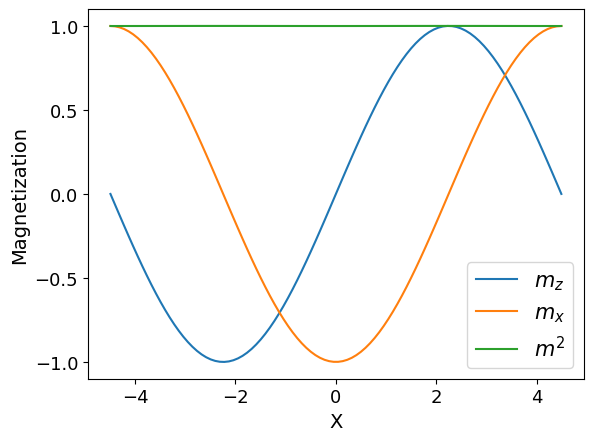

np.float64(0.00027224505616385564)

In [ ]:
magnetization(output1q1,1)

In [ ]:
in_ar1q2 = input_arrays1(np.zeros((4,3)),output1q1,1)
in_arrays1q2 = np.append(-0.7,generate_param1(in_ar1q2,2))
in_arrays1q2

array([-7.00000000e-01,  0.00000000e+00, -4.99936902e-01,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.24969221e-05,  0.00000000e+00,
        0.00000000e+00,  5.00061840e-01,  0.00000000e+00])

In [ ]:
res2 = minimize(energy1, x0 = in_arrays1q2, args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q2 = res2.x
print(res2)
output1q2

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.008483900409680986
        x: [-6.548e-01  0.000e+00 -4.671e-01  0.000e+00  0.000e+00
             9.429e-02  1.766e-01  0.000e+00  8.842e-02  4.995e-01
             0.000e+00]
      nit: 37
      jac: [-1.490e-10  0.000e+00 -5.982e-06  0.000e+00  0.000e+00
            -1.678e-06  1.381e-06  0.000e+00  4.085e-06 -1.257e-07
             0.000e+00]
 hess_inv: [[ 1.054e+00  0.000e+00 ... -1.416e-03  0.000e+00]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [-1.416e-03  0.000e+00 ...  1.268e-04  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
     nfev: 85
     njev: 84


array([-0.65477242,  0.        , -0.46711724,  0.        ,  0.        ,
        0.09429158,  0.17662667,  0.        ,  0.08842403,  0.49949343,
        0.        ])

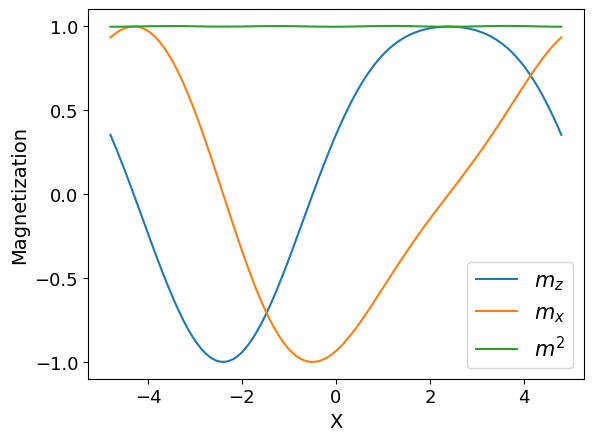

np.float64(0.0025299804277023608)

In [ ]:
magnetization(output1q2,2)

In [ ]:
in_ar1q3 = input_arrays1(np.zeros((4,4)),output1q2,2)
in_arrays1q3 = np.append(output1q2[0],generate_param1(in_ar1q3,3))
in_arrays1q3

array([-0.65477242,  0.        , -0.46711724,  0.        ,  0.        ,
        0.        ,  0.09429158,  0.        ,  0.17662667,  0.        ,
        0.08842403,  0.        ,  0.49949343,  0.        ,  0.        ])

In [ ]:
in_ar1q2

array([[ 0.00000000e+00, -4.99936902e-01,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.24969221e-05,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  5.00061840e-01,  0.00000000e+00]])

In [ ]:
in_ar1q3

array([[ 0.        , -0.46711724,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.09429158,  0.        ],
       [ 0.17662667,  0.        ,  0.08842403,  0.        ],
       [ 0.        ,  0.49949343,  0.        ,  0.        ]])

In [ ]:
res3 = minimize(energy1, x0 = in_arrays1q3, args = (nmax, J, K, D, lamb, H, cod, com),method = 'BFGS', jac = der1)
output1q3 = res3.x
print(res3)
output1q3

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.02347455979923821
        x: [-6.491e-01  0.000e+00 ...  0.000e+00  4.438e-02]
      nit: 59
      jac: [-7.195e-08  0.000e+00 ...  0.000e+00  3.825e-07]
 hess_inv: [[ 9.937e-01  0.000e+00 ...  0.000e+00  4.577e-02]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
            [ 4.577e-02  0.000e+00 ...  0.000e+00  1.936e-02]]
     nfev: 77
     njev: 77


array([-0.649061  ,  0.        , -0.44631685,  0.        , -0.053959  ,
        0.        ,  0.00709856,  0.        ,  0.00977856,  0.        ,
        0.00506253,  0.        ,  0.54387649,  0.        ,  0.04437937])

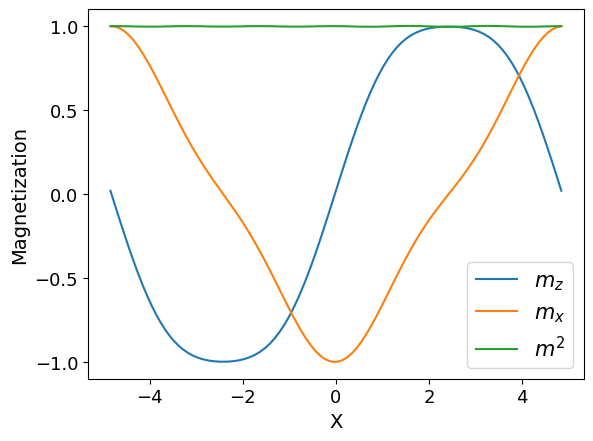

np.float64(0.002693002368209685)

In [ ]:
magnetization(output1q3,3)

In [ ]:
in_ar1q4 = input_arrays1(np.zeros((4,5)),output1q3,3)
in_arrays1q4 = np.append(-0.7,generate_param1(in_ar1q4,4))
in_arrays1q4

array([-0.7       ,  0.        , -0.44631685,  0.        , -0.053959  ,
        0.        ,  0.        ,  0.00709856,  0.        ,  0.        ,
        0.00977856,  0.        ,  0.00506253,  0.        ,  0.        ,
        0.54387649,  0.        ,  0.04437937,  0.        ])

In [ ]:
in_ar1q4

array([[ 0.        , -0.44631685,  0.        , -0.053959  ,  0.        ],
       [ 0.        ,  0.        ,  0.00709856,  0.        ,  0.        ],
       [ 0.00977856,  0.        ,  0.00506253,  0.        ,  0.        ],
       [ 0.        ,  0.54387649,  0.        ,  0.04437937,  0.        ]])

In [ ]:
res4 = minimize(energy1, x0 = in_arrays1q4 , args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q4 = res4.x
print(res4)
output1q4

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.03295233601466102
        x: [-5.785e-01  0.000e+00 ...  4.282e-02  0.000e+00]
      nit: 77
      jac: [ 3.273e-09  0.000e+00 ...  4.411e-07  0.000e+00]
 hess_inv: [[ 1.307e+00  0.000e+00 ...  2.307e-02  0.000e+00]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 2.307e-02  0.000e+00 ...  3.322e-02  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
     nfev: 95
     njev: 95


array([-0.57849874,  0.        , -0.40160031,  0.        , -0.05189264,
        0.        ,  0.        ,  0.11281976,  0.        ,  0.02191877,
        0.17291841,  0.        ,  0.10491913,  0.        ,  0.01883854,
        0.54284049,  0.        ,  0.04281853,  0.        ])

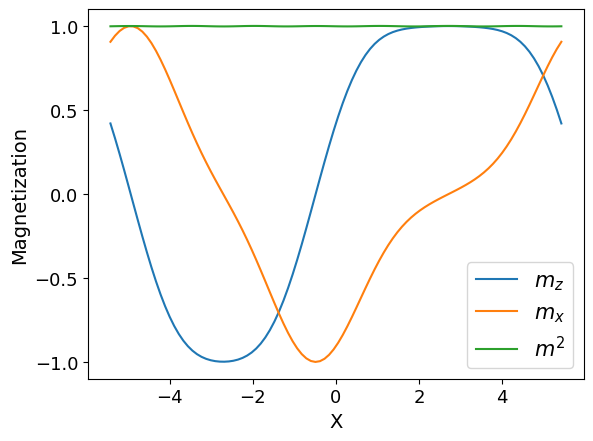

np.float64(0.0015949542297850616)

In [ ]:
magnetization(output1q4,4)

In [ ]:
in_ar1q5 = input_arrays1(np.zeros((4,6)),output1q4,4)
in_arrays1q5 = np.append(output1q4[0],generate_param1(in_ar1q5,5))
in_arrays1q5

array([-0.57849874,  0.        , -0.40160031,  0.        , -0.05189264,
        0.        ,  0.        ,  0.        ,  0.11281976,  0.        ,
        0.02191877,  0.        ,  0.17291841,  0.        ,  0.10491913,
        0.        ,  0.01883854,  0.        ,  0.54284049,  0.        ,
        0.04281853,  0.        ,  0.        ])

In [ ]:
res5 = minimize(energy1, x0 = in_arrays1q5, args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q5 = res5.x
print(res5)
output1q5

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.036360380022131364
        x: [-5.067e-01  0.000e+00 ...  0.000e+00 -9.590e-03]
      nit: 78
      jac: [ 2.125e-09  0.000e+00 ...  0.000e+00 -4.479e-06]
 hess_inv: [[ 1.367e+00  0.000e+00 ...  0.000e+00 -4.556e-02]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
            [-4.556e-02  0.000e+00 ...  0.000e+00  5.187e-03]]
     nfev: 101
     njev: 101


array([-0.50674192,  0.        , -0.34970933,  0.        , -0.01123905,
        0.        ,  0.0108734 ,  0.        ,  0.17517387,  0.        ,
        0.0394131 ,  0.        ,  0.29203219,  0.        ,  0.17832839,
        0.        ,  0.03235843,  0.        ,  0.51917899,  0.        ,
        0.00991707,  0.        , -0.00958995])

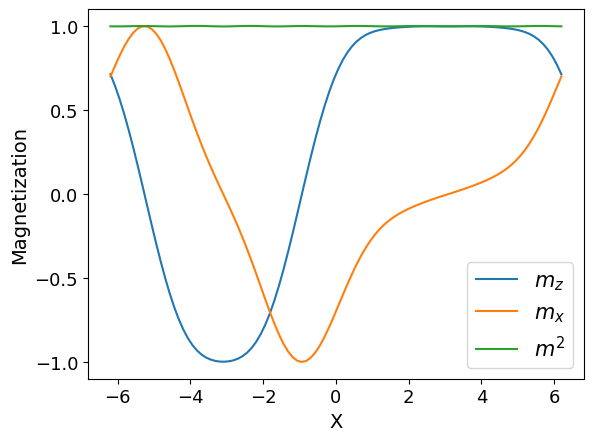

np.float64(0.0015784023293969884)

In [ ]:
magnetization(output1q5,5)

In [ ]:
in_ar1q6 = input_arrays1(np.zeros((4,7)),output1q5,5)
in_arrays1q6 = np.append(output1q5[0],generate_param1(in_ar1q6,6))
in_arrays1q6

array([-0.50674192,  0.        , -0.34970933,  0.        , -0.01123905,
        0.        ,  0.0108734 ,  0.        ,  0.        ,  0.17517387,
        0.        ,  0.0394131 ,  0.        ,  0.        ,  0.29203219,
        0.        ,  0.17832839,  0.        ,  0.03235843,  0.        ,
        0.        ,  0.51917899,  0.        ,  0.00991707,  0.        ,
       -0.00958995,  0.        ])

In [ ]:
res6 = minimize(energy1, x0 = in_arrays1q6 , args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q6 = res6.x
print(res6)
output1q6

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.038281079134481796
        x: [-4.417e-01  0.000e+00 ... -2.153e-02  0.000e+00]
      nit: 84
      jac: [ 4.622e-09  0.000e+00 ... -6.941e-07  0.000e+00]
 hess_inv: [[ 1.334e+00  0.000e+00 ... -7.413e-02  0.000e+00]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [-7.413e-02  0.000e+00 ...  1.512e-02  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
     nfev: 115
     njev: 115


array([-0.44172721,  0.        , -0.29582734,  0.        ,  0.03747762,
        0.        ,  0.02621751,  0.        ,  0.        ,  0.21025498,
        0.        ,  0.0330486 ,  0.        , -0.00627332,  0.38706718,
        0.        ,  0.22712551,  0.        ,  0.02820538,  0.        ,
       -0.00569939,  0.48580171,  0.        , -0.03565576,  0.        ,
       -0.02152524,  0.        ])

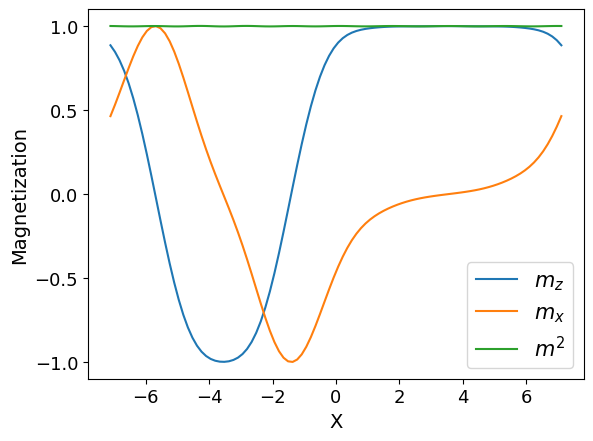

np.float64(0.0015988582773807103)

In [ ]:
magnetization(output1q6,6)

In [ ]:
in_ar1q7 = input_arrays1(np.zeros((4,8)),output1q6,6)
in_arrays1q7 = np.append(output1q6[0],generate_param1(in_ar1q7,7))
in_arrays1q7

array([-0.44172721,  0.        , -0.29582734,  0.        ,  0.03747762,
        0.        ,  0.02621751,  0.        ,  0.        ,  0.        ,
        0.21025498,  0.        ,  0.0330486 ,  0.        , -0.00627332,
        0.        ,  0.38706718,  0.        ,  0.22712551,  0.        ,
        0.02820538,  0.        , -0.00569939,  0.        ,  0.48580171,
        0.        , -0.03565576,  0.        , -0.02152524,  0.        ,
        0.        ])

In [ ]:
res7 = minimize(energy1, x0 = in_arrays1q7, args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q7 = res7.x
print(res7)
output1q7

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.03968222877590466
        x: [-3.889e-01  0.000e+00 ...  0.000e+00  3.729e-03]
      nit: 85
      jac: [-7.335e-09  0.000e+00 ...  0.000e+00  1.108e-06]
 hess_inv: [[ 1.122e+00  0.000e+00 ...  0.000e+00  2.796e-02]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
            [ 2.796e-02  0.000e+00 ...  0.000e+00  2.392e-03]]
     nfev: 110
     njev: 110


array([-0.38892119,  0.        , -0.24824597,  0.        ,  0.08075803,
        0.        ,  0.03136316,  0.        , -0.00413237,  0.        ,
        0.22197259,  0.        ,  0.0112519 ,  0.        , -0.01716865,
        0.        ,  0.46110737,  0.        ,  0.25441984,  0.        ,
        0.00948568,  0.        , -0.01446811,  0.        ,  0.45044952,
        0.        , -0.07895205,  0.        , -0.02596474,  0.        ,
        0.00372896])

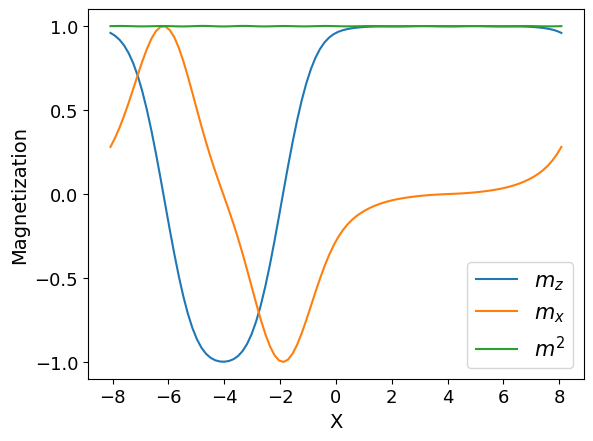

np.float64(0.0015795467603010316)

In [ ]:
magnetization(output1q7,7)

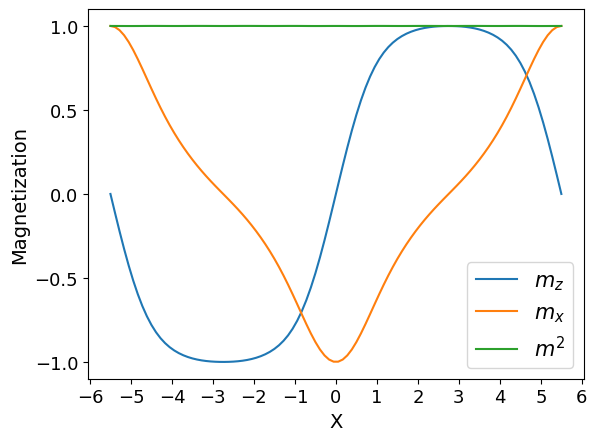

np.float64(0.00029906747727914684)

In [ ]:
magnetization(output1q7,7)

In [ ]:
in_ar1q8 = input_arrays1(np.zeros((4,9)),output1q7,7)
in_arrays1q8 = np.append(output1q7[0],generate_param1(in_ar1q8,8))
in_arrays1q8

array([-0.38892119,  0.        , -0.24824597,  0.        ,  0.08075803,
        0.        ,  0.03136316,  0.        , -0.00413237,  0.        ,
        0.        ,  0.22197259,  0.        ,  0.0112519 ,  0.        ,
       -0.01716865,  0.        ,  0.        ,  0.46110737,  0.        ,
        0.25441984,  0.        ,  0.00948568,  0.        , -0.01446811,
        0.        ,  0.        ,  0.45044952,  0.        , -0.07895205,
        0.        , -0.02596474,  0.        ,  0.00372896,  0.        ])

In [ ]:
res8 = minimize(energy1, x0 = in_arrays1q8, args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q8 = res8.x
print(res8)
output1q8

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.040793137098789414
        x: [-3.466e-01  0.000e+00 ...  1.004e-02  0.000e+00]
      nit: 84
      jac: [ 2.183e-09  0.000e+00 ...  2.171e-07  0.000e+00]
 hess_inv: [[ 1.102e+00  0.000e+00 ...  5.411e-02  0.000e+00]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 5.411e-02  0.000e+00 ...  9.496e-03  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  1.000e+00]]
     nfev: 115
     njev: 115


array([-0.34664182,  0.        , -0.20890837,  0.        ,  0.11263263,
        0.        ,  0.02462026,  0.        , -0.01133524,  0.        ,
        0.        ,  0.21896995,  0.        , -0.01653577,  0.        ,
       -0.02526271,  0.        ,  0.00306312,  0.51956011,  0.        ,
        0.26682658,  0.        , -0.01583999,  0.        , -0.0205599 ,
        0.        ,  0.00260689,  0.41679681,  0.        , -0.11390782,
        0.        , -0.02075798,  0.        ,  0.01004184,  0.        ])

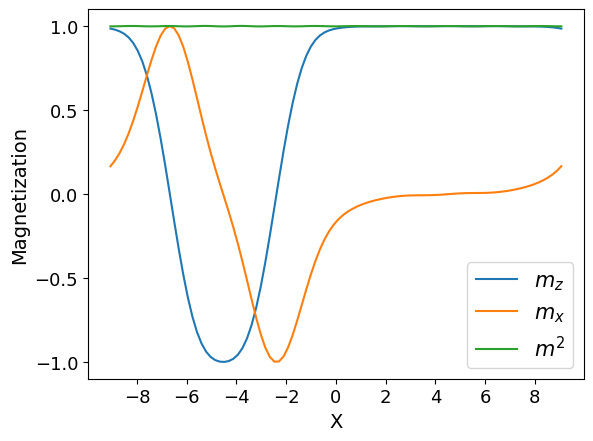

np.float64(0.0015558665139445704)

In [ ]:
magnetization(output1q8,8)

In [ ]:
in_ar1q9 = input_arrays1(np.zeros((4,10)),output1q8,8)
in_arrays1q9 = np.append(output1q8[0],generate_param1(in_ar1q9,9))
in_arrays1q9

array([-0.34664182,  0.        , -0.20890837,  0.        ,  0.11263263,
        0.        ,  0.02462026,  0.        , -0.01133524,  0.        ,
        0.        ,  0.        ,  0.21896995,  0.        , -0.01653577,
        0.        , -0.02526271,  0.        ,  0.00306312,  0.        ,
        0.51956011,  0.        ,  0.26682658,  0.        , -0.01583999,
        0.        , -0.0205599 ,  0.        ,  0.00260689,  0.        ,
        0.41679681,  0.        , -0.11390782,  0.        , -0.02075798,
        0.        ,  0.01004184,  0.        ,  0.        ])

In [ ]:
res9 = minimize(energy1, x0 = in_arrays1q9 , args = (nmax, J, K, D, lamb, H, cod, com), method = 'BFGS', jac = der1)
output1q9 = res9.x
print(res9)
output1q9

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.04169890928787054
        x: [-3.123e-01  0.000e+00 ...  0.000e+00 -1.919e-03]
      nit: 80
      jac: [ 9.280e-09  0.000e+00 ...  0.000e+00  6.616e-07]
 hess_inv: [[ 1.125e+00  0.000e+00 ...  0.000e+00 -1.967e-02]
            [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
            [-1.967e-02  0.000e+00 ...  0.000e+00  1.363e-03]]
     nfev: 113
     njev: 113


array([-0.31233709,  0.        , -0.17701704,  0.        ,  0.13303997,
        0.        ,  0.01006552,  0.        , -0.01939601,  0.        ,
        0.0024961 ,  0.        ,  0.20813883,  0.        , -0.04353371,
        0.        , -0.02560843,  0.        ,  0.00761588,  0.        ,
        0.5667792 ,  0.        ,  0.26982819,  0.        , -0.0418087 ,
        0.        , -0.02113069,  0.        ,  0.00722237,  0.        ,
        0.38605882,  0.        , -0.13971873,  0.        , -0.00838898,
        0.        ,  0.01573427,  0.        , -0.0019187 ])

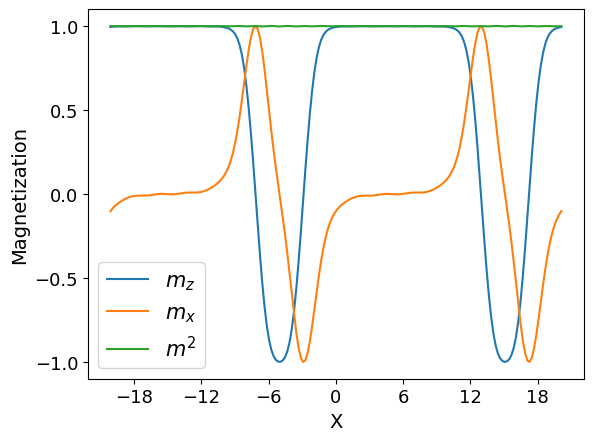

np.float64(0.0015593032058378586)

In [ ]:
magnetization(output1q9,9)

In [ ]:
print(res.fun)
print(res3.fun)
print(res5.fun)
print(res7.fun)
print(res9.fun)


0.004968759055175159
-0.02323510996555135
-0.02966600831728801
-0.030405469146166084
-0.030444619828606183


In [ ]:
print(2*np.pi/res.x[0])
print(2*np.pi/res3.x[0])
print(2*np.pi/res5.x[0])
print(2*np.pi/res7.x[0])
print(2*np.pi/res9.x[0])


-8.975972120989718
-9.693467227656283
-10.664395739724329
-11.000341056290978
-11.000455161412152


In [ ]:
from scipy.integrate import quad

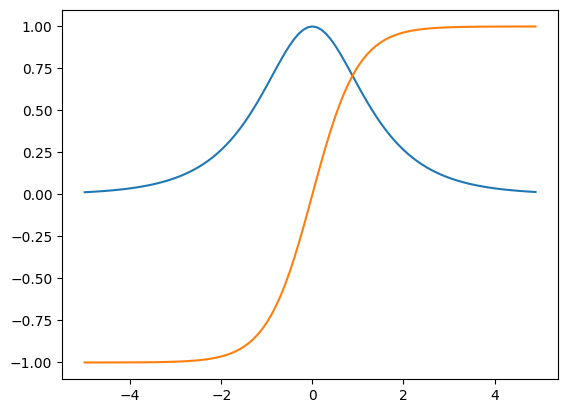

In [ ]:
x = np.arange(-5,5,0.1)
y = np.sqrt(1 - ((np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x)))**2)
z = (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))
plt.plot(x,y)
plt.plot(x,z)

In [ ]:
def fun(x,A):
  return (-A/(2*np.sqrt(A + (np.sin(x))**2)) + np.sqrt(A + (np.sin(x))**2))
def fun2(x,A):
   return np.sqrt(A + (np.sin(x))**2)

In [ ]:
def func(A):
  return quad(fun, 0, np.pi, A)[0]/ quad(fun2, 0, np.pi, A)[0]


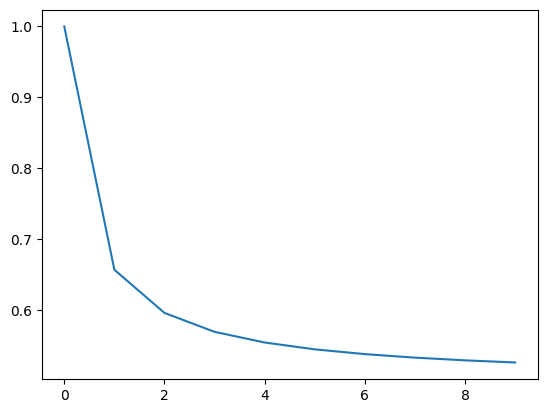

In [ ]:
y = np.arange(0,10,1)
z = []
for i in range(len(y)):
  z.append(func(y[i]))
plt.plot(y,z)


In [ ]:
quad(fun, 0, np.pi, 0)

(2.0, 2.220446049250313e-14)

In [ ]:
from scipy import optimize

In [ ]:
O = minimize(func, 0, method = "Nelder-Mead")
O

       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: 0.5000000000000002
             x: [ 7.206e+14]
           nit: 89
          nfev: 200
 final_simplex: (array([[ 7.206e+14],
                       [ 7.206e+14]]), array([ 5.000e-01,  5.000e-01]))